In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis

# Step 1: Load and inspect data
data = pd.read_csv("weight-height.csv")
print("First 5 rows:")
print(data.head())
print("\nData Info:")
print(data.info())
print("\nMissing Values:")
print(data.isnull().sum())

First 5 rows:
  Gender     Height      Weight
0   Male  73.847017  241.893563
1   Male  68.781904  162.310473
2   Male  74.110105  212.740856
3   Male  71.730978  220.042470
4   Male  69.881796  206.349801

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Gender  10000 non-null  object 
 1   Height  10000 non-null  float64
 2   Weight  10000 non-null  float64
dtypes: float64(2), object(1)
memory usage: 234.5+ KB
None

Missing Values:
Gender    0
Height    0
Weight    0
dtype: int64


In [3]:
# Step 2: Descriptive statistics
print("\nDescriptive Statistics for Height and Weight:")
print(data[["Height", "Weight"]].describe())


Descriptive Statistics for Height and Weight:
             Height        Weight
count  10000.000000  10000.000000
mean      66.367560    161.440357
std        3.847528     32.108439
min       54.263133     64.700127
25%       63.505620    135.818051
50%       66.318070    161.212928
75%       69.174262    187.169525
max       78.998742    269.989699


In [4]:
# Compute mode
height_mode = data["Height"].mode()[0]
weight_mode = data["Weight"].mode()[0]
print(f"\nHeight Mode: {height_mode:.2f}")
print(f"Weight Mode: {weight_mode:.2f}")


Height Mode: 54.26
Weight Mode: 64.70


In [5]:
# Step 3: Skewness and Kurtosis
height_skew = skew(data["Height"])
weight_skew = skew(data["Weight"])
height_kurt = kurtosis(data["Height"], fisher=True)
weight_kurt = kurtosis(data["Weight"], fisher=True)
print("\nSkewness:")
print(f"Height: {height_skew:.2f}")
print(f"Weight: {weight_skew:.2f}")
print("\nKurtosis (Excess):")
print(f"Height: {height_kurt:.2f}")
print(f"Weight: {weight_kurt:.2f}")


Skewness:
Height: 0.05
Weight: 0.03

Kurtosis (Excess):
Height: -0.47
Weight: -0.79


In [6]:
# Step 4: Outliers using IQR
def find_outliers(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers = series[(series < lower_bound) | (series > upper_bound)]
    return lower_bound, upper_bound, outliers

In [7]:
# Height outliers
h_lower, h_upper, h_outliers = find_outliers(data["Height"])
print("\nHeight Outliers:")
print(f"Lower Bound: {h_lower:.2f}, Upper Bound: {h_upper:.2f}")
print(f"Outliers: {h_outliers.values}")

# Weight outliers
w_lower, w_upper, w_outliers = find_outliers(data["Weight"])
print("\nWeight Outliers:")
print(f"Lower Bound: {w_lower:.2f}, Upper Bound: {w_upper:.2f}")
print(f"Outliers: {w_outliers.values}")


Height Outliers:
Lower Bound: 55.00, Upper Bound: 77.68
Outliers: [78.09586747 78.46205292 78.99874235 78.52821043 78.62137397 54.61685783
 54.87372753 54.26313333]

Weight Outliers:
Lower Bound: 58.79, Upper Bound: 264.20
Outliers: [269.98969851]


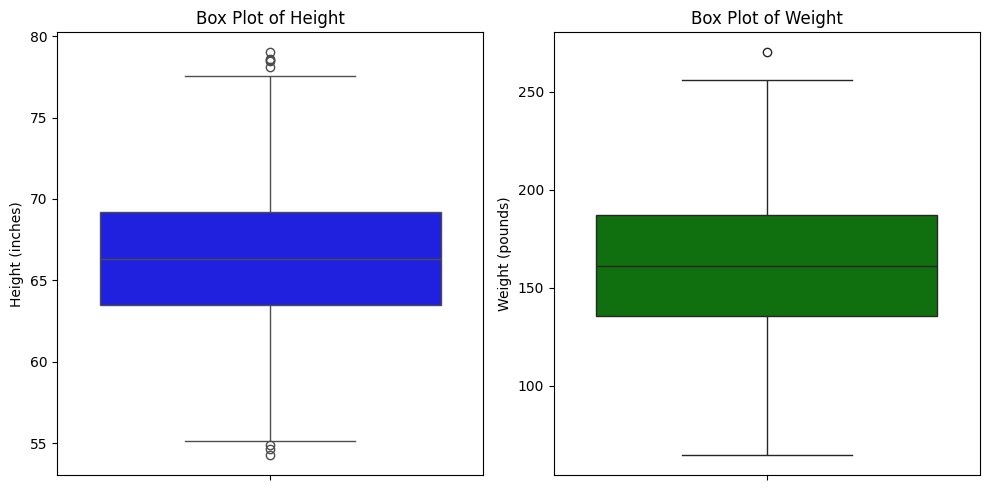

In [9]:
# Step 2: Box Plots for Height and Weight
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
sns.boxplot(y=data["Height"], color="blue")
plt.title("Box Plot of Height")
plt.ylabel("Height (inches)")

plt.subplot(1, 2, 2)
sns.boxplot(y=data["Weight"], color="green")
plt.title("Box Plot of Weight")
plt.ylabel("Weight (pounds)")
plt.tight_layout()
plt.show()

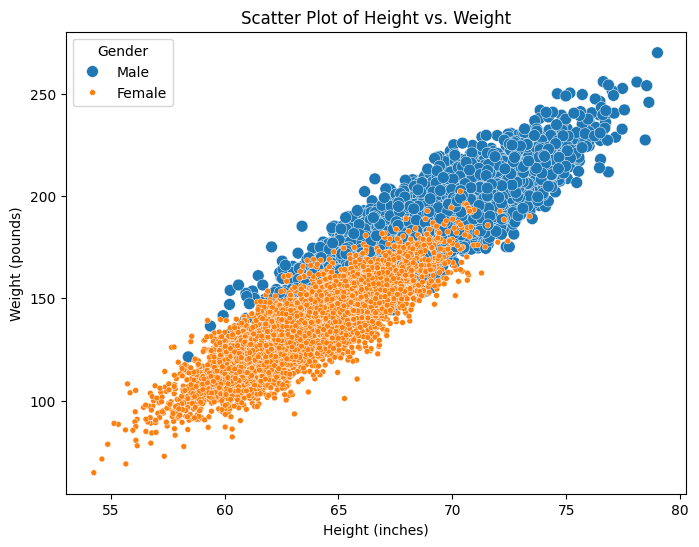

In [10]:
# Step 3: Scatter Plot of Height vs. Weight
plt.figure(figsize=(8, 6))
sns.scatterplot(x="Height", y="Weight", data=data, hue="Gender", size="Gender")
plt.title("Scatter Plot of Height vs. Weight")
plt.xlabel("Height (inches)")
plt.ylabel("Weight (pounds)")
plt.show()

In [11]:
# Step 4: Correlation between Height and Weight
correlation = data[["Height", "Weight"]].corr(method="pearson")
print("\nCorrelation Matrix:")
print(correlation)


Correlation Matrix:
          Height    Weight
Height  1.000000  0.924756
Weight  0.924756  1.000000


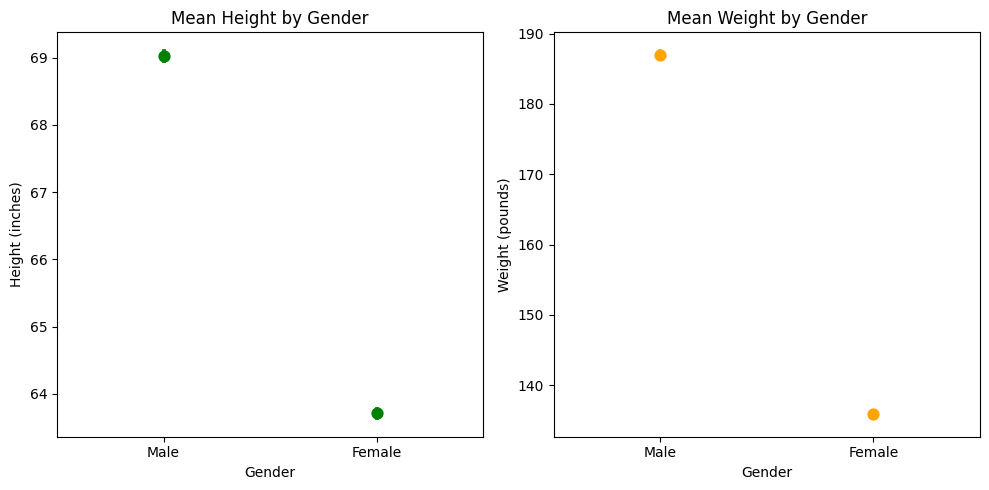

In [18]:
# Step 5: Point Plot for Mean Height and Weight by Gender
if data["Gender"].nunique() > 1:
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    sns.pointplot(x="Gender", y="Height", data=data, color="green", linestyle="none")
    plt.title("Mean Height by Gender")
    plt.ylabel("Height (inches)")
    
    plt.subplot(1, 2, 2)
    sns.pointplot(x="Gender", y="Weight", data=data, color="orange", linestyle="none")
    plt.title("Mean Weight by Gender")
    plt.ylabel("Weight (pounds)")
    plt.tight_layout()
    plt.show()
